# Artificial Intelligence in the Research Literature: An OpenAlex Analysis

DATASCI 530 — Assignment 3

Author: Rola Ke

Data: OpenAlex Works API (https://api.openalex.org/works), retrieved 28 September 2026

## Summary of findings

Using OpenAlex, a free catalogue of scholarly publications, I measured how much research has "artificial intelligence" in its title, where it comes from, which papers are cited most, and how it is spread across research fields. The main finding is rapid and broad growth: works with "artificial intelligence" in the title rose from about 300 a year in 2000 to more than 76,000 in 2025, and the rise began in 2016, well before ChatGPT. The United States, China, and India publish the most AI works, and the ten most-cited papers since 2000 mainly concern healthcare, explainable AI, and education. AI has also moved beyond its home discipline: computer science's share of AI papers fell from 36.5% in 2000–2015 to 21.4% in 2023–2025, while medicine's rose from 6.5% to 28.6%, so medicine is now the largest home of AI papers, ahead of computer science.

## Data and methodology

All data come from the OpenAlex Works API; I saved every response as a JSON file on 28 September 2026 and the notebook reads those files, so every rerun gives the same results. An AI work is any record with the exact phrase "artificial intelligence" in its title (a looser search for the two words anywhere in the title finds only 0.9% more works). Rather than downloading all 330,744 records, I asked the API for counts by year, type, country, and research field, using loops to repeat the request for each search term, period, and page of results. The rankings use works published 2000–2026, while the yearly trends and the field comparison stop at 2025 because 2026 was incomplete; a work with authors in several countries counts once for each country. Table 5 lists the quality checks.

## Setup

In [1]:
import os                                # check whether a saved JSON file exists
import json                              # read and write the saved JSON files
import time                              # retrieval date and a short pause between requests
import requests                          # send requests to the OpenAlex API
import numpy as np                       # bar positions (Figure 2) and missing values (Figure 1)
import pandas as pd                      # tables
import matplotlib.pyplot as plt          # figures
from IPython.display import display      # show the formatted tables

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12,
                     "xtick.labelsize": 11, "ytick.labelsize": 11,
                     "legend.fontsize": 11, "figure.dpi": 110})

In [2]:
# ---- API settings -------------------------------------------------------------
url_openalex_works = "https://api.openalex.org/works"    # OpenAlex Works endpoint (one record = one work)
folder_cache       = "json_files/openalex/"              # folder where every API response is saved
refresh_cache      = False                               # False = reuse saved responses; True = download again
api_key            = os.environ.get("OPENALEX_API_KEY")  # optional free OpenAlex key; None if not set

os.makedirs(folder_cache, exist_ok = True)

# ---- Definition of an "AI work" -------------------------------------------------
# filter_ai: works whose TITLE contains the exact phrase "artificial intelligence".
# The double quotes make OpenAlex search for the phrase, not the two words anywhere.
filter_ai = 'title.search:"artificial intelligence"'

# ---- Readable labels for OpenAlex's "type" codes (Tables 1 and 5) ---------------
dict_type_labels = {"article":          "Journal article",
                    "review":           "Review article",
                    "conference-paper": "Conference paper",
                    "book-chapter":     "Book chapter",
                    "book":             "Book",
                    "preprint":         "Preprint",
                    "paratext":         "Front matter"}

list_checks = []   # rows of Table 5 (quality checks); each section appends (check, result)

In [3]:
# get_json: returns the response to a request, reusing the saved JSON file if the request is exactly the same
def get_json(url, parameters, file_name):
    file_path = folder_cache + file_name + ".json"

    # 1. Reuse the saved response if it came from exactly the same request
    if os.path.exists(file_path) and (refresh_cache == False):
        with open(file_path, "r", encoding = "utf-8") as file:
            saved = json.load(file)
        if saved["parameters"] == parameters:
            return saved["response"]

    # 2. Otherwise call the API. The OpenAlex key is added to the request only, never saved.
    request_parameters = parameters.copy()
    if (url == url_openalex_works) and (api_key is not None):
        request_parameters["api_key"] = api_key

    response = requests.get(url, params = request_parameters, timeout = 60)
    if response.status_code == 429:
        raise RuntimeError("Rate limit reached for " + url + ": wait for the daily reset "
                           "(or set OPENALEX_API_KEY).")
    response.raise_for_status()
    data = response.json()

    with open(file_path, "w", encoding = "utf-8") as file:
        json.dump({"parameters": parameters,
                   "retrieved":  time.strftime("%Y-%m-%d"),
                   "response":   data},
                  file, indent = 4, ensure_ascii = False)
    time.sleep(0.2)
    return data


# get_openalex: same as get_json(), for the OpenAlex Works endpoint
def get_openalex(parameters, file_name):
    return get_json(url_openalex_works, parameters, file_name)


# get_groups: group_by request; returns (one row per group: key, key_display_name, count ; total matching works)
def get_groups(parameters, file_name):
    data   = get_openalex(parameters, file_name)
    groups = pd.DataFrame(data["group_by"], columns = ["key", "key_display_name", "count"])
    return groups, data["meta"]["count"]


# get_all_groups: same as get_groups(), but loops over pages of 200 groups until a page is not full
def get_all_groups(parameters, file_name):
    list_groups = []
    cursor      = "*"                     # "*" = first page
    page        = 1

    while cursor is not None:
        page_parameters = parameters.copy()
        page_parameters["per_page"] = 200
        page_parameters["cursor"]   = cursor

        data        = get_openalex(page_parameters, file_name + "_page" + str(page))
        list_groups = list_groups + data["group_by"]
        cursor      = data["meta"]["next_cursor"]

        if len(data["group_by"]) < 200:   # a page that is not full is the last one
            cursor = None
        page = page + 1

    groups = pd.DataFrame(list_groups, columns = ["key", "key_display_name", "count"])
    return groups, data["meta"]["count"]


# make_table: shows a data frame with a bold caption, number formats and no index column
def make_table(df, caption, formats = {}):
    return (df.style.format(formats)
                    .hide(axis = "index")
                    .set_caption(caption)
                    .set_table_styles([{"selector": "caption", "props": "font-weight: bold; text-align: left; "
                                                                        "font-size: 1.05em; padding-bottom: 6px;"},
                                       {"selector": "th",      "props": "text-align: left;"},
                                       {"selector": "td",      "props": "text-align: left; vertical-align: top;"}]))


# shorten_list: the first n items joined by ", ", plus " and K more" when the list is longer
def shorten_list(items, n):
    if len(items) <= n:
        return ", ".join(items)
    return ", ".join(items[0:n]) + " and " + str(len(items) - n) + " more"

## Question 1: How many works have "artificial intelligence" in their titles?

OpenAlex contains 330,744 works with the exact phrase "artificial intelligence" in the title, counting all years and all types of work. Table 1 shows what kinds of records these are: about 61% are journal articles or reviews.

In [4]:
# q1_phrase, q1_words: raw API responses. per_page = 1 because only meta["count"]
# (the number of matching works) is needed, not the records themselves.
q1_phrase = get_openalex({"filter": filter_ai, "per_page": 1, "select": "id"},
                         "q1_title_phrase")
q1_words  = get_openalex({"filter": "title.search:artificial intelligence", "per_page": 1, "select": "id"},
                         "q1_title_words")

n_ai_titles = q1_phrase["meta"]["count"]     # works with the exact phrase in the title (main definition)
n_ai_words  = q1_words["meta"]["count"]      # works with both words anywhere in the title

# q1_years: one row per publication year, with the number of matching works (all years, all types)
# q1_types: one row per type of work (article, book, ...), with the number of matching works
q1_years, _ = get_groups({"filter": filter_ai, "group_by": "publication_year:include_unknown"}, "q1_by_year")
q1_types, _ = get_groups({"filter": filter_ai, "group_by": "type"}, "q1_by_type")

# OpenAlex returns works with no publication year under the year key -111
q1_years["year"] = q1_years["key"].astype(int)
n_no_year = q1_years.query("year == -111")["count"].sum()

# Checks for Table 5: the year groups and the type groups should both add up to the API total
year_sum = q1_years["count"].sum()      # sum of the year groups (including no year)
type_sum = q1_types["count"].sum()      # sum of the type groups
if (year_sum == n_ai_titles) and (type_sum == n_ai_titles):
    list_checks.append(("Q1: works counted by year and by type add up to the API total", "Yes"))
else:
    list_checks.append(("Q1: works counted by year and by type add up to the API total",
                        f"No: year sum {year_sum:,}, type sum {type_sum:,}, total {n_ai_titles:,}"))
list_checks.append(("Q1: works with no publication year", f"{n_no_year:,}"))
list_checks.append(("Q1: extra works when the two words may appear anywhere in the title",
                    f"{n_ai_words - n_ai_titles:+,} ({(n_ai_words / n_ai_titles - 1) * 100:+.1f}%)"))

In [5]:
# type_table: the six most common types of work, one row for all the others, and the total
q1_types = q1_types.sort_values("count", ascending = False)
q1_types["share"] = q1_types["count"] / n_ai_titles * 100                  # % of all matching works
q1_types["label"] = q1_types["key_display_name"].replace(dict_type_labels)  # readable type name

type_table = q1_types.iloc[0:6][["label", "count", "share"]]
other_row  = pd.DataFrame({"label": ["Other types (" + str(len(q1_types) - 6) + ")"],
                           "count": [q1_types.iloc[6:]["count"].sum()],
                           "share": [q1_types.iloc[6:]["share"].sum()]})
total_row  = pd.DataFrame({"label": ["All types"], "count": [n_ai_titles], "share": [100.0]})
type_table = pd.concat([type_table, other_row, total_row])

display(make_table(type_table.rename(columns = {"label": "Type of work",
                                                "count": "Works",
                                                "share": "Share of all works"}),
                   'Table 1. Works with "artificial intelligence" in the title, by type of work (all years)',
                   {"Works": "{:,.0f}", "Share of all works": "{:.1f}%"}))

Type of work,Works,Share of all works
Journal article,"194,293",58.7%
Conference paper,"39,889",12.1%
Book chapter,"24,902",7.5%
Preprint,"22,993",7.0%
Review article,"8,174",2.5%
Book,"7,114",2.2%
Other types (19),"33,379",10.1%
All types,"330,744",100.0%


## Question 2: Which countries publish the most on artificial intelligence since 2000?

I grouped the 2000–2026 AI works by the countries in the authors' affiliations. Table 2 shows the 20 countries with the most works.

In [6]:
# filter_since_2000: AI works published 2000–2026 (used for Questions 2 and 3)
filter_since_2000 = filter_ai + ",publication_year:2000-2026"

# countries: one row per country (plus "UNKNOWN") with the number of AI works that have at
# least one author affiliated with that country. Full counting: a work with authors in two
# countries is counted once for each, so the counts add up to more than the number of works.
countries, n_works_q2 = get_all_groups({"filter":   filter_since_2000,
                                        "group_by": "authorships.countries:include_unknown"},
                                       "q2_countries")

# The key is a URL such as "https://openalex.org/countries/US": keep the code at the end
countries["country_code"] = countries["key"].str.split("/").str[-1]
countries = countries.rename(columns = {"key_display_name": "country", "count": "publications"})

n_unknown       = countries.query('country_code == "UNKNOWN"')["publications"].sum()  # works with no country
countries_known = countries.query('country_code != "UNKNOWN"').copy()                   # real countries only
n_works_known   = n_works_q2 - n_unknown      # works with at least one known country = denominator of the shares

countries_known["share"] = countries_known["publications"] / n_works_known * 100
countries_known["rank"]  = countries_known["publications"].rank(method = "min", ascending = False)
countries_known = countries_known.sort_values("publications", ascending = False)

# Checks for Table 5
n_2026 = q1_years.query("year == 2026")["count"].sum()     # works dated 2026, from the Question 1 year groups
list_checks.append(("Q2: works published 2000–2026", f"{n_works_q2:,}"))
list_checks.append(("Q2: of which published in 2026 (partial year)",
                    f"{n_2026:,} ({n_2026 / n_works_q2 * 100:.1f}%)"))
list_checks.append(("Q2: works with no country information",
                    f"{n_unknown:,} ({n_unknown / n_works_q2 * 100:.1f}%)"))
list_checks.append(("Q2: countries per work, among works with a known country",
                    f"{countries_known['publications'].sum() / n_works_known:.2f}"))

# Table 2: the 20 countries with the most AI works
display(make_table(countries_known.iloc[0:20][["rank", "country", "publications", "share"]]
                       .rename(columns = {"rank":         "Rank",
                                          "country":      "Country",
                                          "publications": "AI works",
                                          "share":        "Share of AI works"}),
                   'Table 2. The 20 countries with the most works with "artificial intelligence" in the title, '
                   '2000–2026 (shares are of works with a known country; a work with authors in several '
                   'countries counts once for each)',
                   {"Rank": "{:.0f}", "AI works": "{:,.0f}", "Share of AI works": "{:.1f}%"}))

Rank,Country,AI works,Share of AI works
1,United States,"36,515",18.0%
2,China,"29,722",14.6%
3,India,"24,672",12.2%
4,United Kingdom,"12,464",6.1%
5,Indonesia,"8,795",4.3%
6,Italy,"7,311",3.6%
7,Germany,"6,790",3.3%
8,Turkey,"6,595",3.2%
9,Russia,"5,895",2.9%
10,Canada,"5,795",2.9%


The United States leads with 36,515 AI works, or 18.0% of the works with a known country, followed by China (29,722) and India (24,672). Country information is missing for 36.9% of the works, so the table describes only the works with recorded affiliations.

## Question 3: The ten most-cited papers on artificial intelligence since 2000

I sorted the 2000–2026 AI works by citation count and kept only journal articles and reviews, so that the ranking compares papers of the same kind. Among the 25 most-cited records of any type, six were books, conference papers, front matter, or a preprint (Table 5). Table 3 lists the ten papers with their citations, authors, and institutions; long lists are shortened.

In [7]:
# top_any: the 25 most-cited AI works of ANY type, 2000–2026 (to see what a restriction
# to journal articles and reviews removes)
top_any_type = get_openalex({"filter":   filter_since_2000,
                             "sort":     "cited_by_count:desc",
                             "per_page": 25,
                             "select":   "id,doi,display_name,publication_year,type,cited_by_count"},
                            "q3_top_cited_any_type")
top_any = pd.DataFrame(top_any_type["results"])

# not_papers: the records among these 25 that are not journal articles or reviews
# type_counts: number of these records per readable type of work
not_papers  = top_any.query('(type != "article") & (type != "review")')
type_counts = not_papers["type"].replace(dict_type_labels).value_counts().sort_index()
list_checks.append(("Q3: records among the 25 most-cited that are not journal articles or reviews",
                    f"{len(not_papers)} (" + ", ".join([f"{label} {n}" for label, n in type_counts.items()]) + ")"))

# top_papers: raw API response with the 10 most-cited journal articles and reviews, 2000–2026
top_papers = get_openalex({"filter":   filter_since_2000 + ",type:article|review",
                           "sort":     "cited_by_count:desc",
                           "per_page": 10,
                           "select":   "id,display_name,publication_year,type,cited_by_count,"
                                       "authorships,primary_location,is_retracted"},
                          "q3_top_cited_papers")

# top10: one row per paper, built with a loop over the papers and their "authorships"
# (one authorship = one author on the paper, with that author's institutions)
list_papers = []
rank = 1
for work in top_papers["results"]:

    list_authors      = []     # author names, each listed once
    list_institutions = []     # institution names, each listed once, in order of appearance
    n_no_institution  = 0      # authors with no institution recorded
    n_duplicates      = 0      # authorships that repeat an author already listed

    for authorship in work["authorships"]:
        # Duplicates are found by name, not by author ID (OpenAlex author IDs can be missing)
        name = authorship["author"]["display_name"]
        if name in list_authors:
            n_duplicates = n_duplicates + 1
            continue
        list_authors.append(name)

        if len(authorship["institutions"]) == 0:
            n_no_institution = n_no_institution + 1
        for institution in authorship["institutions"]:
            if institution["display_name"] not in list_institutions:
                list_institutions.append(institution["display_name"])

    list_papers.append({"rank":             rank,
                        "id":               work["id"],
                        "title":            work["display_name"],
                        "year":             work["publication_year"],
                        "citations":        work["cited_by_count"],
                        "is_retracted":     work["is_retracted"],
                        "authors":          list_authors,
                        "institutions":     list_institutions,
                        "n_duplicates":     n_duplicates,
                        "n_authors":        len(list_authors),          # after removing duplicates
                        "n_no_institution": n_no_institution})
    rank = rank + 1

top10 = pd.DataFrame(list_papers)

# Checks for Table 5 (duplicates, retractions, missing institutions)
n_distinct = min(top10["id"].nunique(), top10["title"].str.lower().nunique())
list_checks.append(("Q3: top-ten papers with distinct IDs and titles", f"{n_distinct} of {len(top10)}"))
list_checks.append(("Q3: retracted papers", f"{top10['is_retracted'].sum()}"))
list_checks.append(("Q3: duplicate author entries removed", f"{top10['n_duplicates'].sum()}"))
list_checks.append(("Q3: authors with no institution recorded",
                    f"{top10['n_no_institution'].sum()} of {top10['n_authors'].sum()}"))

In [8]:
# Shortened author and institution lists (first 3 names)
top10["authors_text"]      = [shorten_list(authors, 3) for authors in top10["authors"]]
top10["institutions_text"] = [shorten_list(institutions, 3) for institutions in top10["institutions"]]

display(make_table(top10[["rank", "title", "year", "citations", "authors_text", "institutions_text"]]
                       .rename(columns = {"rank":              "Rank",
                                          "title":             "Title",
                                          "year":              "Year",
                                          "citations":         "Citations",
                                          "authors_text":      "Authors",
                                          "institutions_text": "Institutions"}),
                   'Table 3. The ten most-cited journal articles and reviews with "artificial intelligence" '
                   'in the title, 2000–2026',
                   {"Citations": "{:,.0f}"}))

Rank,Title,Year,Citations,Authors,Institutions
1,High-performance medicine: the convergence of human and artificial intelligence,2018,"10,188",Eric J. Topol,Scripps Research Institute
2,"Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI",2019,"10,067","Alejandro Barredo Arrieta, Natalia Díaz-Rodríguez, Javier Del Ser and 9 more","Tecnalia, Institut national de recherche en sciences et technologies du numérique, École Nationale Supérieure de Techniques Avancées and 7 more"
3,Systematic review of research on artificial intelligence applications in higher education – where are the educators?,2019,"6,754","Olaf Zawacki‐Richter, Victoria I. Marín, Melissa Bond and 1 more",Carl von Ossietzky Universität Oldenburg
4,Peeking Inside the Black-Box: A Survey on Explainable Artificial Intelligence (XAI),2018,"6,281","Amina Adadi, Mohammed Berrada",Sidi Mohamed Ben Abdellah University
5,Explanation in artificial intelligence: Insights from the social sciences,2018,"5,241",Tim Miller,The University of Melbourne
6,"Artificial intelligence in healthcare: past, present and future",2017,"4,885","Fei Jiang, Yong Jiang, Hui Zhi and 7 more","University of Hong Kong, Capital Medical University, Beijing Tian Tan Hospital and 2 more"
7,"Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy",2019,"4,497","Yogesh Kumar Dwivedi, Laurie Hughes, Elvira Ismagilova and 32 more","Prin. L. N. Welingkar Institute of Management Development and Research, Swansea University, University of Bradford and 15 more"
8,Artificial Intelligence in Education: A Review,2020,"3,963","Lijia Chen, Pingping Chen, Zhijian Lin","Yango University, Fuzhou University"
9,The potential for artificial intelligence in healthcare,2019,"3,851","Thomas H. Davenport, Ravi Kalakota","Babson College, Deloitte (United States)"
10,Artificial intelligence in radiology,2018,"3,809","Ahmed Hosny, Chintan Parmar, John Quackenbush and 2 more","Harvard University, Dana-Farber Cancer Institute, NewYork–Presbyterian Hospital and 4 more"


The most-cited paper is Eric Topol's 2018 "High-performance medicine: the convergence of human and artificial intelligence" with 10,188 citations, followed closely by "Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI" by Alejandro Barredo Arrieta and colleagues (10,067). All ten papers were published between 2017 and 2020, and their titles mainly concern healthcare, explainable AI, and education.

## Question 4: How has the number of publications changed from year to year?

For each of four search terms I requested the number of works per year from 2000 to 2025; Figure 1 plots them and Table 4 gives the counts for selected years. I added "machine learning" because it is a long-established part of AI, in contrast with the newer terms "LLM" (large language model) and "GPT" (the model family behind ChatGPT). Because both abbreviations can mean other things, I checked a random sample of 25 titles from before 2020 for each: none contained "language model", so the small early counts mostly reflect other meanings of the abbreviations.

In [9]:
list_keywords = ["artificial intelligence", "LLM", "GPT", "machine learning"]   # search terms
list_years    = list(range(2000, 2026))                                          # complete years only

list_yearly   = []     # one small table (year, keyword, count) per term
list_mismatch = []     # terms whose yearly counts do not add up to the API total
for keyword in list_keywords:
    name = keyword.lower().replace(" ", "_")

    # works: number of works (all types) with the term in the title, per year; n_works: API total
    works, n_works = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2000-2025',
                                 "group_by": "publication_year"},
                                "q4_years_" + name)
    if works["count"].sum() != n_works:
        list_mismatch.append(f"{keyword}: {works['count'].sum():,} vs {n_works:,}")

    works["year"]    = works["key"].astype(int)
    works["keyword"] = keyword
    list_yearly.append(works[["year", "keyword", "count"]])

if len(list_mismatch) == 0:
    list_checks.append(("Q4: yearly counts add up to the API total for all four terms", "Yes"))
else:
    list_checks.append(("Q4: yearly counts add up to the API total for all four terms", "No: " + "; ".join(list_mismatch)))

# yearly_works: one row per year, one column per term; years with no works = 0
yearly_works = (pd.concat(list_yearly).pivot(index = "year", columns = "keyword", values = "count")
                  .reindex(index = list_years, columns = list_keywords).fillna(0))

# yearly_change: % change in the number of works from the previous year
yearly_change = yearly_works.pct_change() * 100

# Random samples of 25 pre-2020 titles for the two acronyms (fixed seed so the sample is reproducible)
for keyword in ["GPT", "LLM"]:
    sample = get_openalex({"filter":   'title.search:"' + keyword + '",publication_year:2000-2019',
                           "sample":   25,
                           "seed":     530,
                           "per_page": 25,
                           "select":   "display_name,publication_year"},
                          "q4_sample_early_" + keyword.lower())
    titles = pd.Series([work["display_name"] for work in sample["results"]])
    k      = titles.str.lower().str.contains("language model").sum()   # sampled titles about language models
    list_checks.append((f'Q4: sampled "{keyword}" titles from 2000–2019 that contain "language model"',
                        f"{k} of {len(titles)}"))

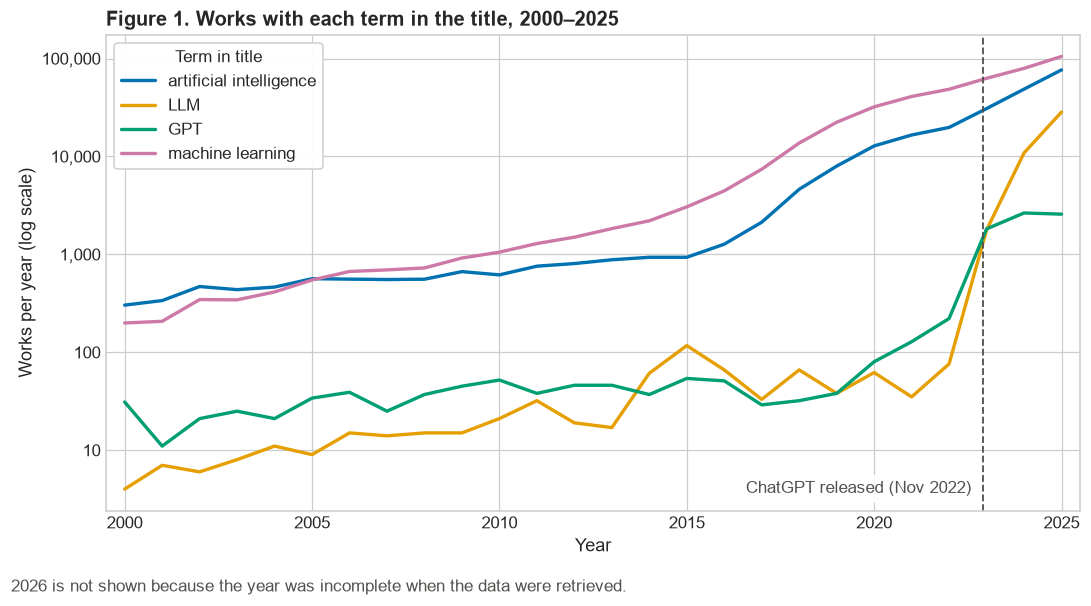

In [10]:
# dict_colors: one fixed colour-blind-safe colour per term (Okabe-Ito palette)
dict_colors = {"artificial intelligence": "#0072B2",
               "LLM":                     "#E69F00",
               "GPT":                     "#009E73",
               "machine learning":        "#CC79A7"}

fig, ax = plt.subplots(figsize = (10, 5.5))

for keyword in list_keywords:
    values = yearly_works[keyword].replace(0, np.nan)          # a log scale cannot show 0
    ax.plot(values.index, values, color = dict_colors[keyword], linewidth = 2.2, label = keyword)

ax.set_yscale("log")
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.axvline(2022.9, color = "#52514e", linestyle = "--", linewidth = 1.2)
ax.text(2022.6, 0.03, "ChatGPT released (Nov 2022)", transform = ax.get_xaxis_transform(),
        ha = "right", va = "bottom", fontsize = 11, color = "#52514e",
        bbox = {"facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax.set_title("Figure 1. Works with each term in the title, 2000–2025", loc = "left",
             fontsize = 13, fontweight = "bold")
ax.set_xlabel("Year")
ax.set_ylabel("Works per year (log scale)")
ax.set_xlim(1999.5, 2025.5)
ax.set_xticks(range(2000, 2026, 5))
ax.legend(title = "Term in title", loc = "upper left", frameon = True, framealpha = 0.95)

fig.text(0.01, 0.01, "2026 is not shown because the year was incomplete when the data were retrieved.",
         fontsize = 11, color = "#52514e")
fig.tight_layout(rect = (0, 0.04, 1, 1))
plt.show()

In [11]:
list_show_years = [2000, 2010, 2015, 2020, 2022, 2023, 2024, 2025]    # years shown in Table 4

# growth: Table 4, one row per term
growth = yearly_works.loc[list_show_years].T
growth.columns = [str(year) for year in list_show_years]
growth["Change from 2024 to 2025"] = yearly_change.loc[2025]
growth = growth.reset_index().rename(columns = {"keyword": "Term"})

dict_format = {}
for year in list_show_years:
    dict_format[str(year)] = "{:,.0f}"
dict_format["Change from 2024 to 2025"] = "{:+.0f}%"

display(make_table(growth, "Table 4. Works with each term in the title in selected years, 2000–2025",
                   dict_format))


Term,2000,2010,2015,2020,2022,2023,2024,2025,Change from 2024 to 2025
artificial intelligence,303,617,933,"12,805","19,781","30,828","48,684","76,545",+57%
LLM,4,21,117,62,76,"1,772","10,865","28,384",+161%
GPT,31,52,54,80,221,"1,819","2,646","2,573",-3%
machine learning,199,"1,053","3,054","32,102","48,565","62,806","79,372","105,008",+32%


Works with "artificial intelligence" in the title rose from about 300 in 2000 to 76,545 in 2025. The growth began well before ChatGPT, around 2016 (Figure 1): the yearly count rose from 933 in 2015 to 12,805 in 2020. "Machine learning" is now the more common term, with 105,008 works in 2025, but AI is catching up, growing 57% from 2024 to 2025 compared with 32% for machine learning. "LLM" barely appeared before 2023 and then jumped to 28,384 works in 2025, an increase of 161% in one year, while "GPT" stayed at about 2,600 works in both 2024 and 2025.

## New insight (Questions 5 and 6): Has AI research moved between fields?

To see whether AI is still mainly a computer-science topic, I grouped AI papers (journal articles and reviews) by the main research field OpenAlex assigns to each, in three periods: before the rise (2000–2015), the rise (2016–2022), and the years after ChatGPT (2023–2025). Figure 2 shows each field's share of all AI papers in each period for the ten fields with the most AI papers in 2023–2025.

In [12]:
# The three periods compared
dict_periods = {"2000–2015": "2000-2015",
                "2016–2022": "2016-2022",
                "2023–2025": "2023-2025"}

list_fields   = []     # one small table (field, count) per period
list_totals   = []     # AI papers per period (API totals), for Table 5
list_mismatch = []     # periods whose field counts do not add up to the period total
for period in dict_periods:
    years = dict_periods[period]
    name  = years.replace("-", "_")

    # ai_groups: AI articles and reviews in the period, per primary research field; n_ai_period: API total
    ai_groups, n_ai_period = get_groups({"filter":   filter_ai + ",publication_year:" + years + ",type:article|review",
                                         "group_by": "primary_topic.field.id:include_unknown"},
                                        "q5_fields_ai_" + name)
    if ai_groups["count"].sum() != n_ai_period:
        list_mismatch.append(period)
    list_totals.append(f"{n_ai_period:,} in {period}")

    ai_groups["period"] = period
    list_fields.append(ai_groups)

# fields_all: one row per field and period (papers_ai = AI articles and reviews in the field)
fields_all = pd.concat(list_fields).rename(columns = {"key_display_name": "field", "count": "papers_ai"})
n_no_field = fields_all.query('field == "unknown"')["papers_ai"].sum()     # AI papers with no research field

# Check for Table 5
if len(list_mismatch) == 0:
    result = "Yes (AI papers: " + "; ".join(list_totals) + ")"
else:
    result = "No: " + ", ".join(list_mismatch)
if n_no_field == 0:
    result = result + "; none without a research field"
else:
    result = result + f"; {n_no_field:,} without a research field"
list_checks.append(("Q5: field counts add up to the period totals", result))

# fields: the same without the unknown field
#   share_ai = the field's share of all AI papers in the period (%)
fields = fields_all.query('field != "unknown"').copy()
fields["share_ai"] = fields["papers_ai"] / fields.groupby("period")["papers_ai"].transform("sum") * 100

# share_wide: one row per field, one column per period
share_wide = fields.pivot(index = "field", columns = "period", values = "share_ai").fillna(0)

# The ten fields with the most AI papers in 2023–2025 (shown in Figure 2)
list_top_fields = share_wide.sort_values("2023–2025", ascending = False).index[0:10]

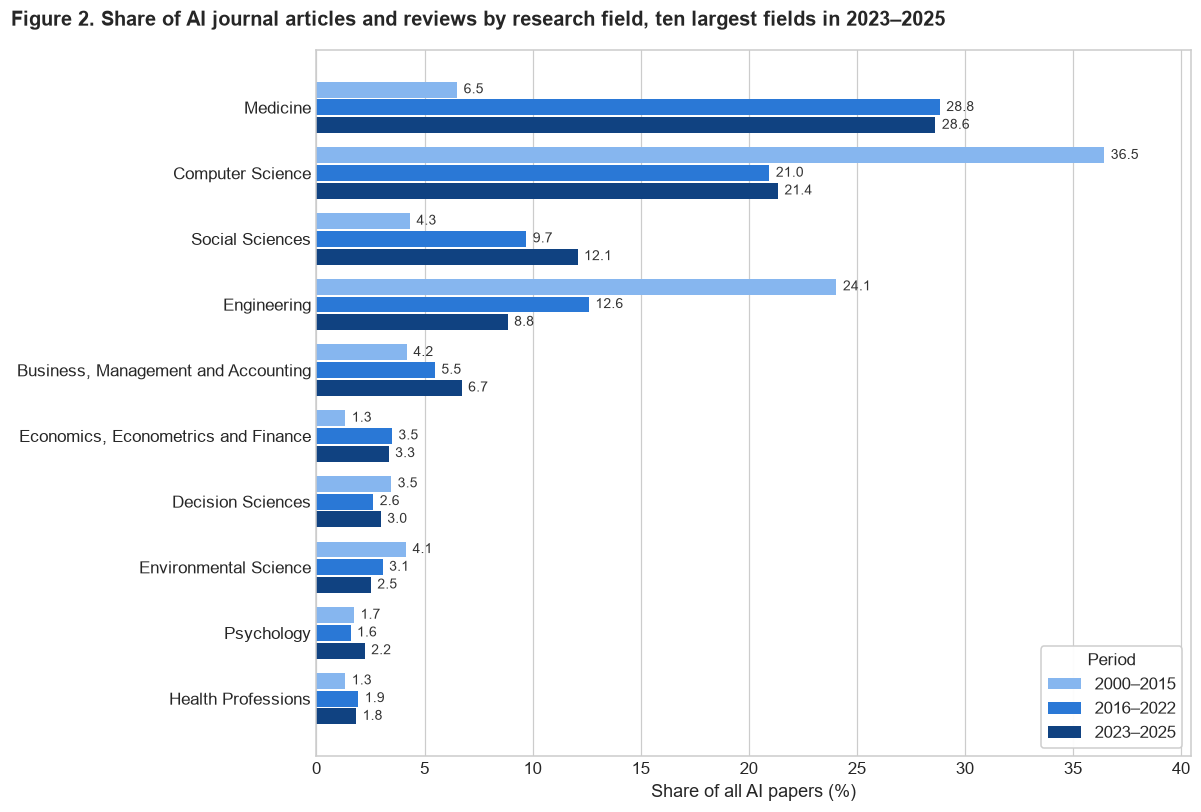

In [13]:
list_plot_fields   = list(list_top_fields)[::-1]           # largest field at the top
list_period_colors = ["#86b6ef", "#2a78d6", "#104281"]     # light = early period, dark = recent
positions          = np.arange(len(list_plot_fields))
bar_height         = 0.27

fig, ax = plt.subplots(figsize = (11, 7.5))

# Grouped bars: one bar per period for each field, with the value at the end of each bar
index = 0
for period in dict_periods:
    bar_positions = positions - (index - 1) * bar_height
    values        = share_wide.loc[list_plot_fields, period]
    ax.barh(bar_positions, values, height = bar_height * 0.9, color = list_period_colors[index], label = period)
    for j in range(len(list_plot_fields)):
        ax.text(values.iloc[j] + 0.3, bar_positions[j], f"{values.iloc[j]:.1f}",
                va = "center", fontsize = 9, color = "#333")
    index = index + 1

ax.set_xlim(0, share_wide.loc[list_plot_fields].max().max() + 4)   # room for the value labels
ax.set_yticks(positions)
ax.set_yticklabels(list_plot_fields)
ax.set_xlabel("Share of all AI papers (%)")
ax.grid(axis = "y", visible = False)
ax.legend(title = "Period", loc = "lower right", frameon = True, framealpha = 0.95)

fig.suptitle("Figure 2. Share of AI journal articles and reviews by research field, ten largest fields in 2023–2025",
             fontsize = 13, fontweight = "bold", x = 0.01, ha = "left")
fig.tight_layout()
plt.show()

### What we learn

AI research has spread well beyond computer science, and most of that shift happened before the recent language-model boom. Computer science's share of AI papers fell from 36.5% in 2000–2015 to about 21% in both later periods, while medicine's rose from 6.5% to about 29%. Their shares were almost the same in 2016–2022 and 2023–2025, while engineering's share fell and the social sciences' share rose across the three periods. In short, medicine has overtaken computer science as the largest home of AI papers.

## Quality checks

Table 5 collects the quality checks I ran while building the tables above. The year, type, field, and term counts add up to the API totals, and the ten top papers are distinct and none is retracted.

In [14]:
# table_checks: Table 5, one row per quality check appended in the sections above
table_checks = pd.DataFrame(list_checks, columns = ["Check", "Result"])
display(make_table(table_checks, "Table 5. Quality checks"))

Check,Result
Q1: works counted by year and by type add up to the API total,Yes
Q1: works with no publication year,"1,311"
Q1: extra works when the two words may appear anywhere in the title,"+2,954 (+0.9%)"
Q2: works published 2000–2026,"321,844"
Q2: of which published in 2026 (partial year),"90,830 (28.2%)"
Q2: works with no country information,"118,835 (36.9%)"
"Q2: countries per work, among works with a known country",1.32
Q3: records among the 25 most-cited that are not journal articles or reviews,"6 (Book 2, Conference paper 2, Front matter 1, Preprint 1)"
Q3: top-ten papers with distinct IDs and titles,10 of 10
Q3: retracted papers,0
